Statistical Test

Purpose is to show why I selected Mann-Whitney U with Benjamini-Hochberg FDR correction

Considerations:
Are per-group distributions approximately normal?
Are variances equal between groups?
How many multiple comparisons are we doing?

In [ ]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent
DB_PATH = ROOT / 'loblaw.db'
assert DB_PATH.exists(), 'Run `python load_data.py` first.'

Load the analysis cohort

Filter: melanoma + miraclib + PBMC, exclude rows with NULL response.

In [ ]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query("""
        SELECT sub.subject_id, sub.sex,
               s.sample_id, s.response, s.time_from_treatment_start AS timepoint,
               cc.population, cc.count,
               100.0 * cc.count / SUM(cc.count) OVER (PARTITION BY s.sample_id) AS percentage
        FROM subjects sub
        JOIN samples s ON s.subject_id = sub.subject_id
        JOIN cell_counts cc ON cc.sample_id = s.sample_id
        WHERE sub.condition = 'melanoma'
          AND s.treatment = 'miraclib'
          AND s.sample_type = 'PBMC'
          AND s.response IS NOT NULL
    """, conn)

print(f'Rows: {len(df):,}')
print(f'Subjects: {df.subject_id.nunique()},  Samples: {df.sample_id.nunique()}')
print('\nGroup sizes per (response × timepoint × population):')
print(df.groupby(['timepoint','response','population']).size().unstack('population'))

Rows: 9,840
Subjects: 656,  Samples: 1968

Group sizes per (response × timepoint × population):
population          b_cell  cd4_t_cell  cd8_t_cell  monocyte  nk_cell
timepoint response                                                   
0         no           325         325         325       325      325
          yes          331         331         331       331      331
7         no           325         325         325       325      325
          yes          331         331         331       331      331
14        no           325         325         325       325      325
          yes          331         331         331       331      331


Visual check: distributions per group

Histograms with KDE overlay for each population x timepoint, split by response. Looking for: skewness, multimodality, outliers

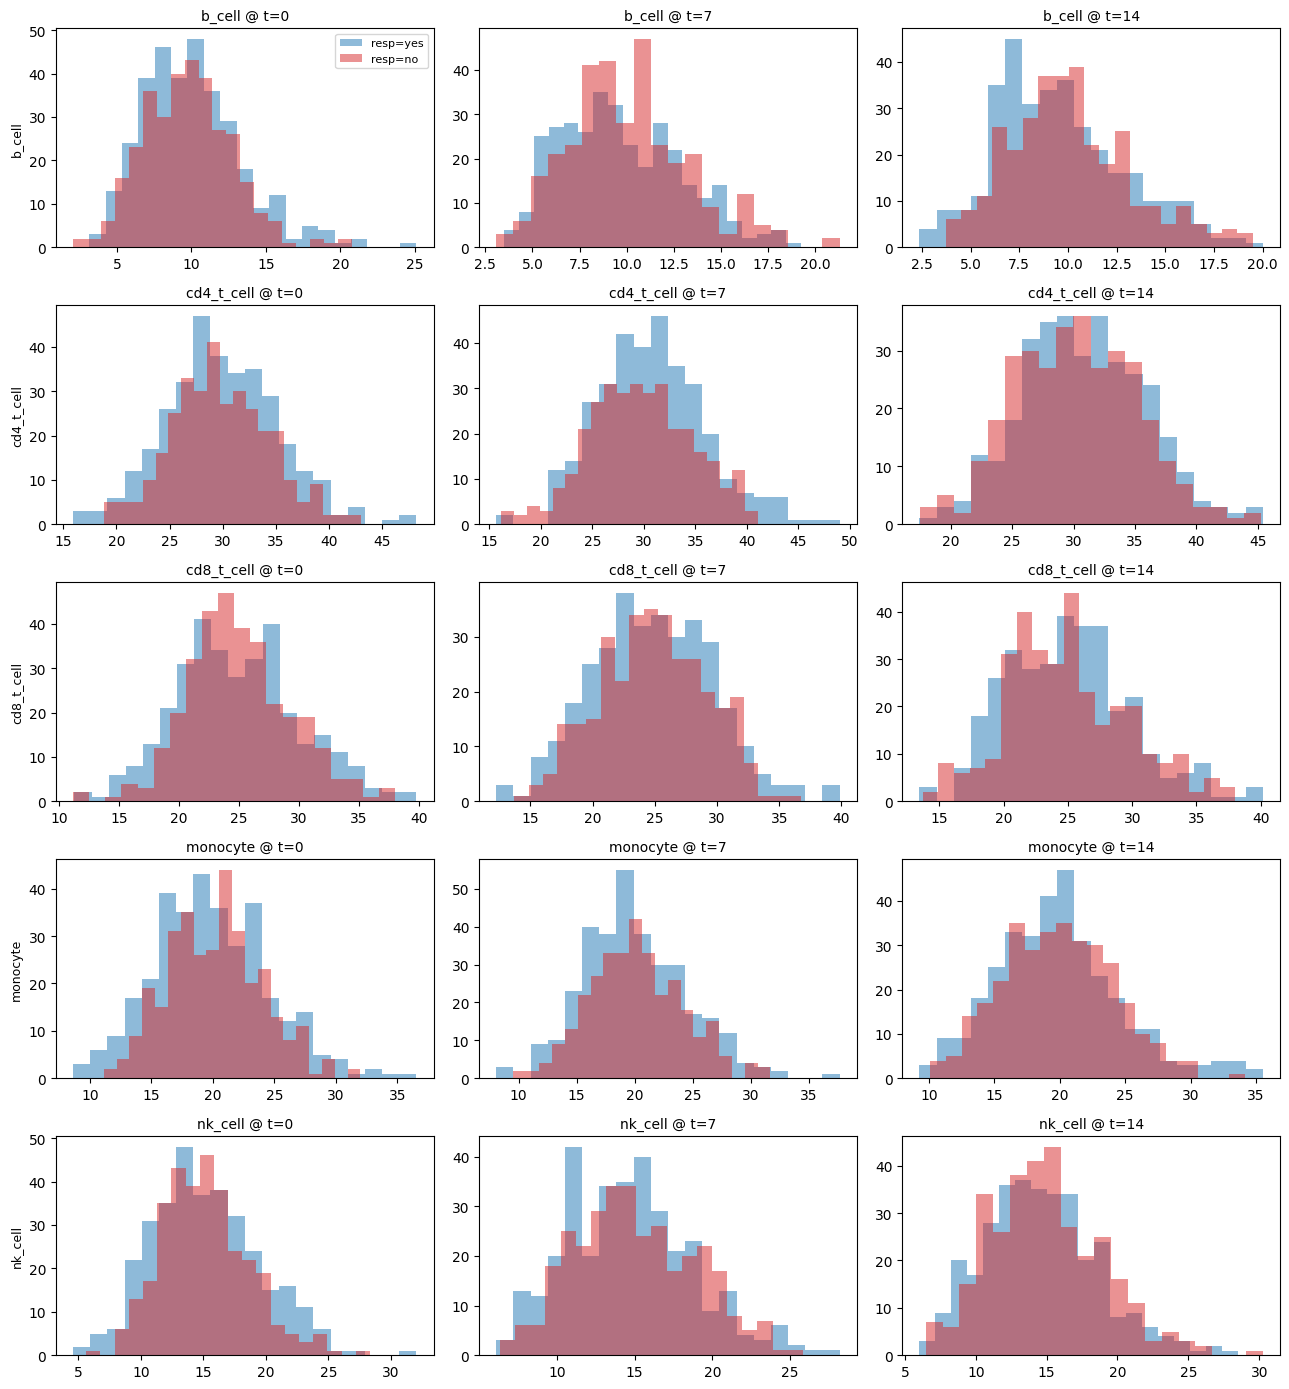

In [3]:
populations = sorted(df.population.unique())
timepoints = sorted(df.timepoint.unique())

fig, axes = plt.subplots(len(populations), len(timepoints), figsize=(13, 14))
for i, pop in enumerate(populations):
    for j, tp in enumerate(timepoints):
        ax = axes[i, j]
        sub = df[(df.population == pop) & (df.timepoint == tp)]
        for resp, color in [('yes', '#1f77b4'), ('no', '#d62728')]:
            vals = sub.loc[sub.response == resp, 'percentage']
            ax.hist(vals, bins=20, alpha=0.5, color=color, label=f'resp={resp}')
        ax.set_title(f'{pop} @ t={tp}', fontsize=10)
        if j == 0: ax.set_ylabel(pop, fontsize=9)
        if i == 0 and j == 0: ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Q-Q plots: normality

Points should lie on diagonal if normal; Systematic curvature means non-normal.

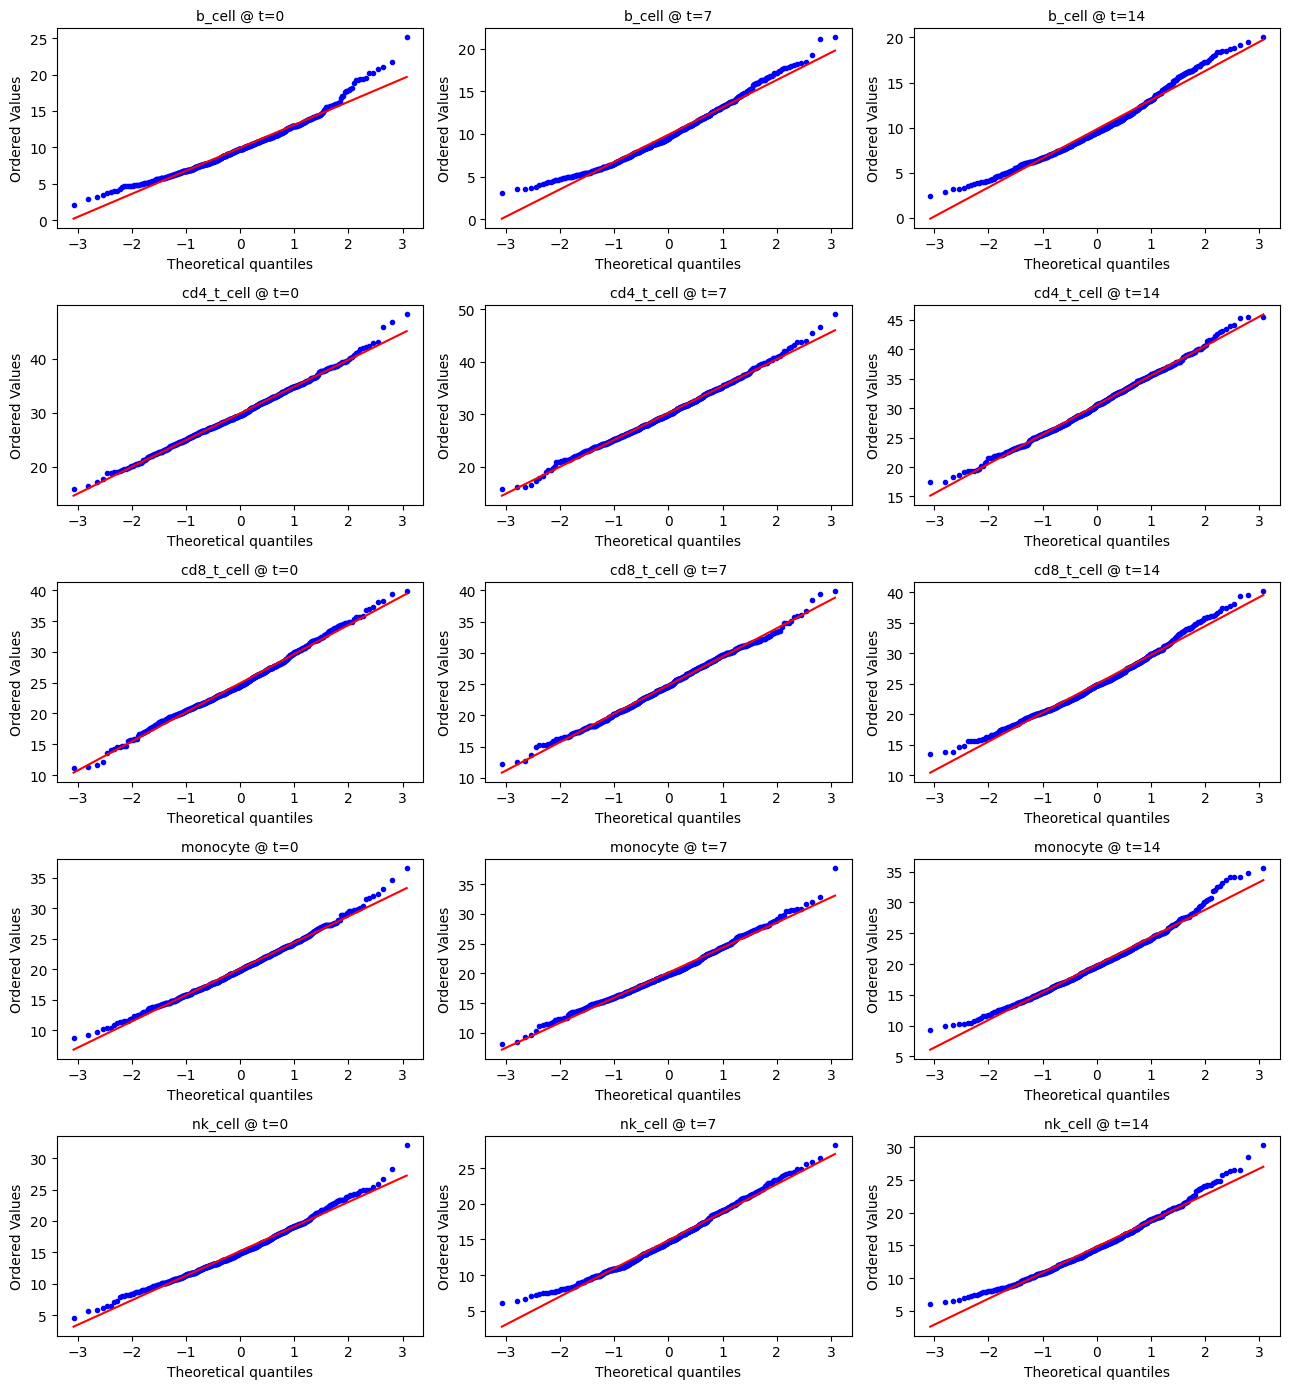

In [4]:
fig, axes = plt.subplots(len(populations), len(timepoints), figsize=(13, 14))
for i, pop in enumerate(populations):
    for j, tp in enumerate(timepoints):
        ax = axes[i, j]
        vals = df[(df.population == pop) & (df.timepoint == tp)]['percentage']
        stats.probplot(vals, dist='norm', plot=ax)
        ax.set_title(f'{pop} @ t={tp}', fontsize=10)
        ax.get_lines()[0].set_markersize(3)
plt.tight_layout()
plt.show()

Shapiro-Wilk for normality

H0: data drawn from normal dist, if p < 0.05 then reject normality

With n ≈ 325 per group, Shapiro-Wilk is really powerful. It'tt reject normality for tiny deviations. 

In [5]:
rows = []
for pop in populations:
    for tp in timepoints:
        for resp in ['yes', 'no']:
            vals = df[(df.population == pop) & (df.timepoint == tp) & (df.response == resp)]['percentage']
            stat, p = stats.shapiro(vals)
            rows.append({'population': pop, 'timepoint': tp, 'response': resp,
                         'n': len(vals), 'shapiro_stat': stat, 'shapiro_p': p,
                         'normal_at_alpha_05': p > 0.05})
shapiro_df = pd.DataFrame(rows)
print(f'Groups rejecting normality (p<0.05): {(~shapiro_df.normal_at_alpha_05).sum()} / {len(shapiro_df)}')
shapiro_df

Groups rejecting normality (p<0.05): 19 / 30


,population,timepoint,response,n,shapiro_stat,shapiro_p,normal_at_alpha_05
0,b_cell,0,yes,331,0.958021,3.870095e-08,False
1,b_cell,0,no,325,0.985184,2.013932e-03,False
2,b_cell,7,yes,331,0.975961,2.472273e-05,False
3,b_cell,7,no,325,0.978994,1.084032e-04,False
4,b_cell,14,yes,331,0.975719,2.233591e-05,False
5,b_cell,14,no,325,0.977137,4.844513e-05,False
6,cd4_t_cell,0,yes,331,0.995399,4.367887e-01,True
7,cd4_t_cell,0,no,325,0.996423,6.818661e-01,True
8,cd4_t_cell,7,yes,331,0.989452,1.718936e-02,False
9,cd4_t_cell,7,no,325,0.993706,1.952730e-01,True


Levene's test for equal variances

H0: responder and non-responder groups have equal variance. p < 0.05 so reject equal variances

In [6]:
rows = []
for pop in populations:
    for tp in timepoints:
        sub = df[(df.population == pop) & (df.timepoint == tp)]
        yes = sub.loc[sub.response == 'yes', 'percentage']
        no = sub.loc[sub.response == 'no', 'percentage']
        stat, p = stats.levene(yes, no, center='median')  # Brown-Forsythe variant, robust
        rows.append({'population': pop, 'timepoint': tp,
                     'levene_stat': stat, 'levene_p': p,
                     'equal_var_at_alpha_05': p > 0.05})
levene_df = pd.DataFrame(rows)
print(f'Comparisons with unequal variance (p<0.05): {(~levene_df.equal_var_at_alpha_05).sum()} / {len(levene_df)}')
levene_df

Comparisons with unequal variance (p<0.05): 5 / 15


,population,timepoint,levene_stat,levene_p,equal_var_at_alpha_05
0,b_cell,0,3.045630,0.081424,True
1,b_cell,7,0.464521,0.495760,True
2,b_cell,14,1.157044,0.282476,True
3,cd4_t_cell,0,6.365505,0.011872,False
4,cd4_t_cell,7,0.188857,0.664013,True
5,cd4_t_cell,14,0.021183,0.884327,True
6,cd8_t_cell,0,11.368093,0.000791,False
7,cd8_t_cell,7,5.511780,0.019186,False
8,cd8_t_cell,14,0.122255,0.726714,True
9,monocyte,0,10.648181,0.001159,False


Conclusion:

Normality is violated for at least some groups. Q-Q plots show curvature in several populations; Shapiro-Wilk rejects normality for many.
Variances aren't equal across responder/non-responder groups
Sample sizes are good enough (about 325 per group per timepoint)

Decision: Mann-Whitney U test

Reasoning:
No normality assumption
No equal-variance assumption
High relative efficiency when data is normal


Multiple comparisons: Benjamini-Hochberg FDR with alpha = 0.05

Reasoning:
We run 15 tests (5 populations x 3 timepoints) on same hypotheses type
Bonferroni is too conservative
BH controls the false discovery rate